In [48]:
from pathlib import Path
import os
import hashlib

import pandas as pd
import numpy as np

from PIL import Image
import matplotlib.pyplot as plt
import imagehash
from pathlib import Path
import os

from dotenv import load_dotenv



# I. DATA STRUCTURE

# 1 .Xem DATASET có gì

In [49]:
load_dotenv()

project_dir = Path.cwd()
if project_dir.name == "notebooks":
    project_dir = project_dir.parent

DATA_DIR = Path(os.getenv("DATA_DIR") or project_dir.parent / "PlantVillage")

TRAIN_DIR = DATA_DIR / "train"
VAL_DIR = DATA_DIR / "val"

print(DATA_DIR)
print(TRAIN_DIR.exists())
print(VAL_DIR.exists())

d:\Plant_disease\PlantVillage
True
True


# 2. Lấy danh sách class và đếm số class từng file

In [50]:
train_classes = sorted([p.name for p in TRAIN_DIR.iterdir() if p.is_dir()])
val_classes = sorted([p.name for p in VAL_DIR.iterdir() if p.is_dir()])

print("Số class train:", len(train_classes))
print("Số class val:", len(val_classes))

print("\nMột vài class train:")
print(train_classes[:10])

Số class train: 38
Số class val: 38

Một vài class train:
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight']


In [51]:
print("Class chỉ có trong train:")
print(set(train_classes) - set(val_classes))

print("\nClass chỉ có trong val:")
print(set(val_classes) - set(train_classes))

Class chỉ có trong train:
set()

Class chỉ có trong val:
set()


# 3. Đếm ảnh và tạo bảng số lượng từng class

In [52]:
IMAGE_EXTS = {".jpg", ".jpeg", ".png"}

def count_images(folder):
    return sum(
        1
        for path in folder.rglob("*")
        if path.is_file()
        and path.suffix.lower() in IMAGE_EXTS
    )

n_train = count_images(TRAIN_DIR)
n_val = count_images(VAL_DIR)

print("Train images:", n_train)
print("Val images:", n_val)
print("Total:", n_train + n_val)

Train images: 43444
Val images: 10861
Total: 54305


In [53]:
total = n_train + n_val

print(f"Train: {n_train / total:.2%}")
print(f"Val:   {n_val / total:.2%}")

Train: 80.00%
Val:   20.00%


In [54]:
def count_images_per_class(split_dir):
    result = {}

    for class_dir in split_dir.iterdir():
        if not class_dir.is_dir():
            continue

        count = sum(
            1
            for path in class_dir.iterdir()
            if path.is_file()
            and path.suffix.lower() in IMAGE_EXTS
        )

        result[class_dir.name] = count

    return result

In [55]:
train_counts = count_images_per_class(TRAIN_DIR)
val_counts = count_images_per_class(VAL_DIR)

split_summary = pd.DataFrame({
    "class_name": train_classes,
    "train_count": [
        train_counts.get(cls, 0)
        for cls in train_classes
    ],
    "val_count": [
        val_counts.get(cls, 0)
        for cls in train_classes
    ]
})

split_summary["total"] = (
    split_summary["train_count"]
    + split_summary["val_count"]
)

split_summary.head()

,class_name,train_count,val_count,total
0,Apple___Apple_scab,504,126,630
1,Apple___Black_rot,496,125,621
2,Apple___Cedar_apple_rust,220,55,275
3,Apple___healthy,1316,329,1645
4,Blueberry___healthy,1202,300,1502


# II. TẠO BẢNG METADATA

In [56]:
records = []

for split in ["train", "val"]:

    split_dir = DATA_DIR / split

    for class_dir in split_dir.iterdir():

        if not class_dir.is_dir():
            continue

        class_name = class_dir.name

        plant, condition = class_name.split("___", 1)

        for img_path in class_dir.iterdir():

            if (
                img_path.is_file()
                and img_path.suffix.lower() in IMAGE_EXTS
            ):

                records.append({
                    "relative_path": str(
                        img_path.relative_to(DATA_DIR)
                    ),
                    "split": split,
                    "class_name": class_name,
                    "plant": plant,
                    "condition": condition,
                    "is_healthy":
                        condition.lower() == "healthy"
                })

df = pd.DataFrame(records)

In [57]:
METADATA_DIR = Path("../data/metadata")
METADATA_DIR.mkdir(parents=True, exist_ok=True)

df.to_csv(
    METADATA_DIR / "metadata.csv",
    index=False
)

# III. Thống kê tổng quan DATASET

In [58]:
total_images = len(df)

train_images = (df["split"] == "train").sum()
val_images = (df["split"] == "val").sum()

num_classes = df["class_name"].nunique()
num_plants = df["plant"].nunique()

healthy_images = df["is_healthy"].sum()
diseased_images = (~df["is_healthy"]).sum()

In [59]:
summary = pd.DataFrame({
    "metric": [
        "Total images",
        "Train images",
        "Validation images",
        "Number of classes",
        "Number of plant types",
        "Healthy images",
        "Diseased images"
    ],
    "value": [
        total_images,
        train_images,
        val_images,
        num_classes,
        num_plants,
        healthy_images,
        diseased_images
    ]
})

summary

,metric,value
0,Total images,54305
1,Train images,43444
2,Validation images,10861
3,Number of classes,38
4,Number of plant types,14
5,Healthy images,15084
6,Diseased images,39221


In [60]:
# Tỉ lệ healthy/diseased
print(f"Healthy ratio: {healthy_images / total_images:.2%}")
print(f"Diseased ratio: {diseased_images / total_images:.2%}")

Healthy ratio: 27.78%
Diseased ratio: 72.22%


In [61]:
# Số loại cây

plant_counts = df["plant"].value_counts()

plant_counts

plant
Tomato                     18160
Orange                      5507
Soybean                     5090
Grape                       4062
Corn_(maize)                3852
Apple                       3171
Peach                       2657
Pepper,_bell                2475
Potato                      2152
Cherry_(including_sour)     1906
Squash                      1835
Strawberry                  1565
Blueberry                   1502
Raspberry                    371
Name: count, dtype: int64

# IV. Phân bố lớp

In [62]:
# Số ảnh mỗi class

class_distribution = (
    df["class_name"]
    .value_counts()
    .reset_index()
)

class_distribution.columns = [
    "class_name",
    "count"
]

class_distribution

,class_name,count
0,Orange___Haunglongbing_(Citrus_greening),5507
1,Tomato___Tomato_Yellow_Leaf_Curl_Virus,5357
2,Soybean___healthy,5090
3,Peach___Bacterial_spot,2297
4,Tomato___Bacterial_spot,2127
5,Tomato___Late_blight,1909
6,Squash___Powdery_mildew,1835
7,Tomato___Septoria_leaf_spot,1771
8,Tomato___Spider_mites Two-spotted_spider_mite,1676
9,Apple___healthy,1645


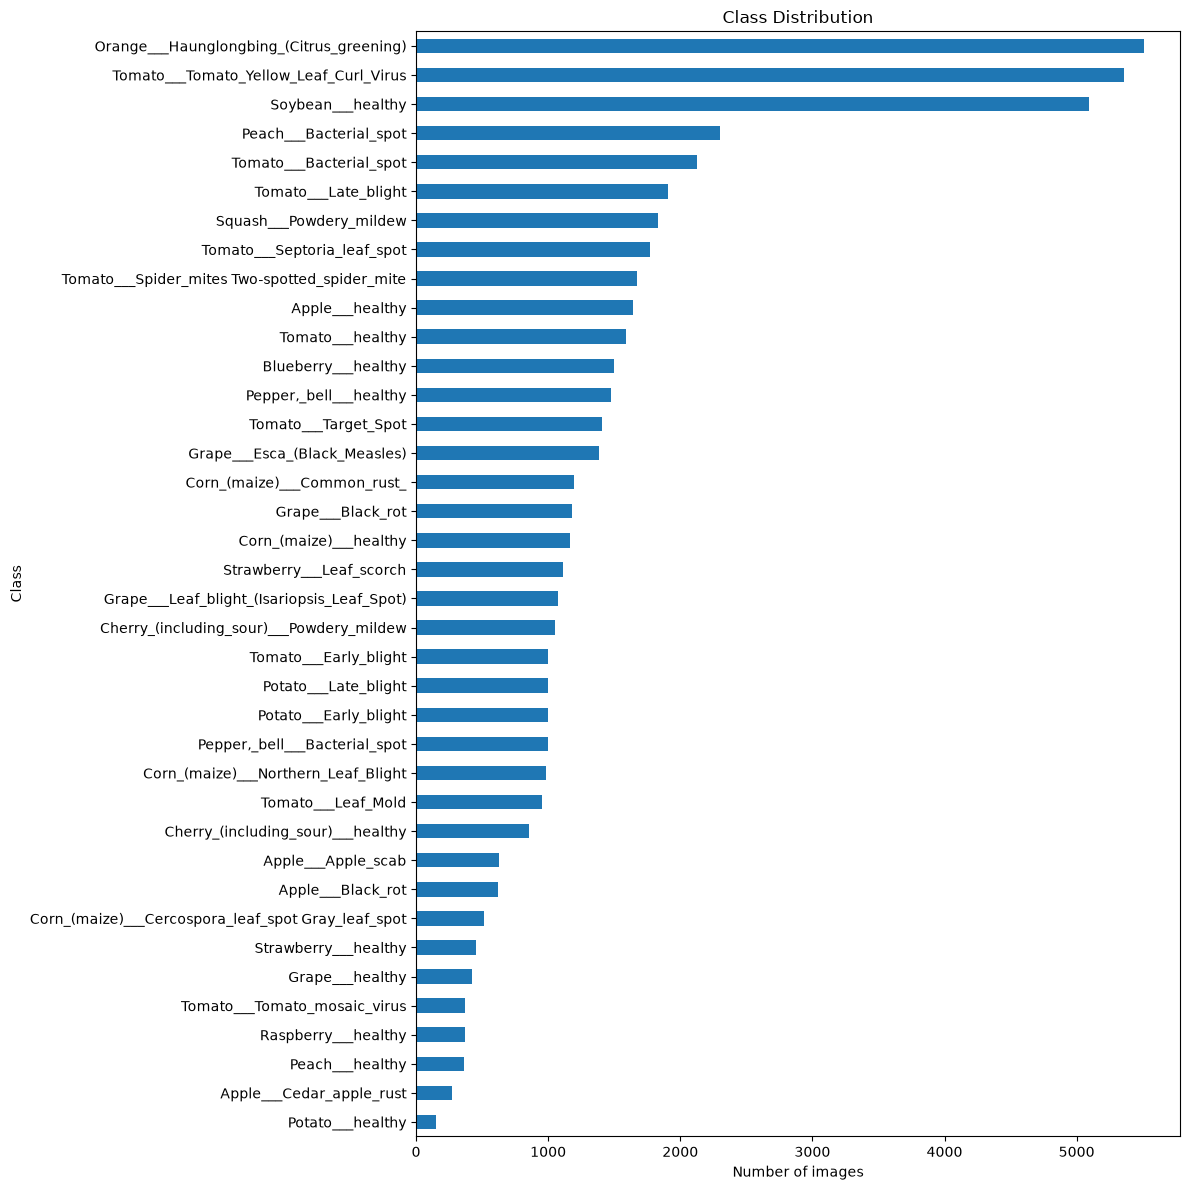

In [63]:
class_counts = (
    df["class_name"]
    .value_counts()
)

plt.figure(figsize=(12, 12))

class_counts.sort_values(
    ascending=True
).plot(
    kind="barh"
)

plt.xlabel("Number of images")
plt.ylabel("Class")
plt.title("Class Distribution")

plt.tight_layout()
plt.show()

In [64]:
# So sánh giữa class lớn nhất và nhỏ nhất 

max_count = class_counts.max()
min_count = class_counts.min()

imbalance_ratio = max_count / min_count

print("Largest class:", class_counts.idxmax())
print("Largest class count:", max_count)

print("Smallest class:", class_counts.idxmin())
print("Smallest class count:", min_count)

print(f"Imbalance ratio: {imbalance_ratio:.2f}")

Largest class: Orange___Haunglongbing_(Citrus_greening)
Largest class count: 5507
Smallest class: Potato___healthy
Smallest class count: 152
Imbalance ratio: 36.23


In [65]:
class_counts.describe()

count      38.000000
mean     1429.078947
std      1271.738784
min       152.000000
25%       686.000000
50%      1092.500000
75%      1631.500000
max      5507.000000
Name: count, dtype: float64

In [66]:
split_class_counts = (
    df.groupby(["class_name", "split"])
    .size()
    .unstack(fill_value=0)
)

# So sánh train và val theo từng class

split_class_counts["total"] = (
    split_class_counts.get("train", 0)
    + split_class_counts.get("val", 0)
)

split_class_counts

split,train,val,total
class_name,,,
Apple___Apple_scab,504,126,630
Apple___Black_rot,496,125,621
Apple___Cedar_apple_rust,220,55,275
Apple___healthy,1316,329,1645
Blueberry___healthy,1202,300,1502
Cherry_(including_sour)___Powdery_mildew,842,210,1052
Cherry_(including_sour)___healthy,684,170,854
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot,410,103,513
Corn_(maize)___Common_rust_,953,239,1192


In [67]:
# Tính tỉ lệ validation

split_class_counts["val_ratio"] = (
    split_class_counts["val"]
    / split_class_counts["total"]
)

split_class_counts[
    ["train", "val", "total", "val_ratio"]
]

split,train,val,total,val_ratio
class_name,,,,
Apple___Apple_scab,504,126,630,0.200000
Apple___Black_rot,496,125,621,0.201288
Apple___Cedar_apple_rust,220,55,275,0.200000
Apple___healthy,1316,329,1645,0.200000
Blueberry___healthy,1202,300,1502,0.199734
Cherry_(including_sour)___Powdery_mildew,842,210,1052,0.199620
Cherry_(including_sour)___healthy,684,170,854,0.199063
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot,410,103,513,0.200780
Corn_(maize)___Common_rust_,953,239,1192,0.200503


- Tỉ lệ validation đều nhau 

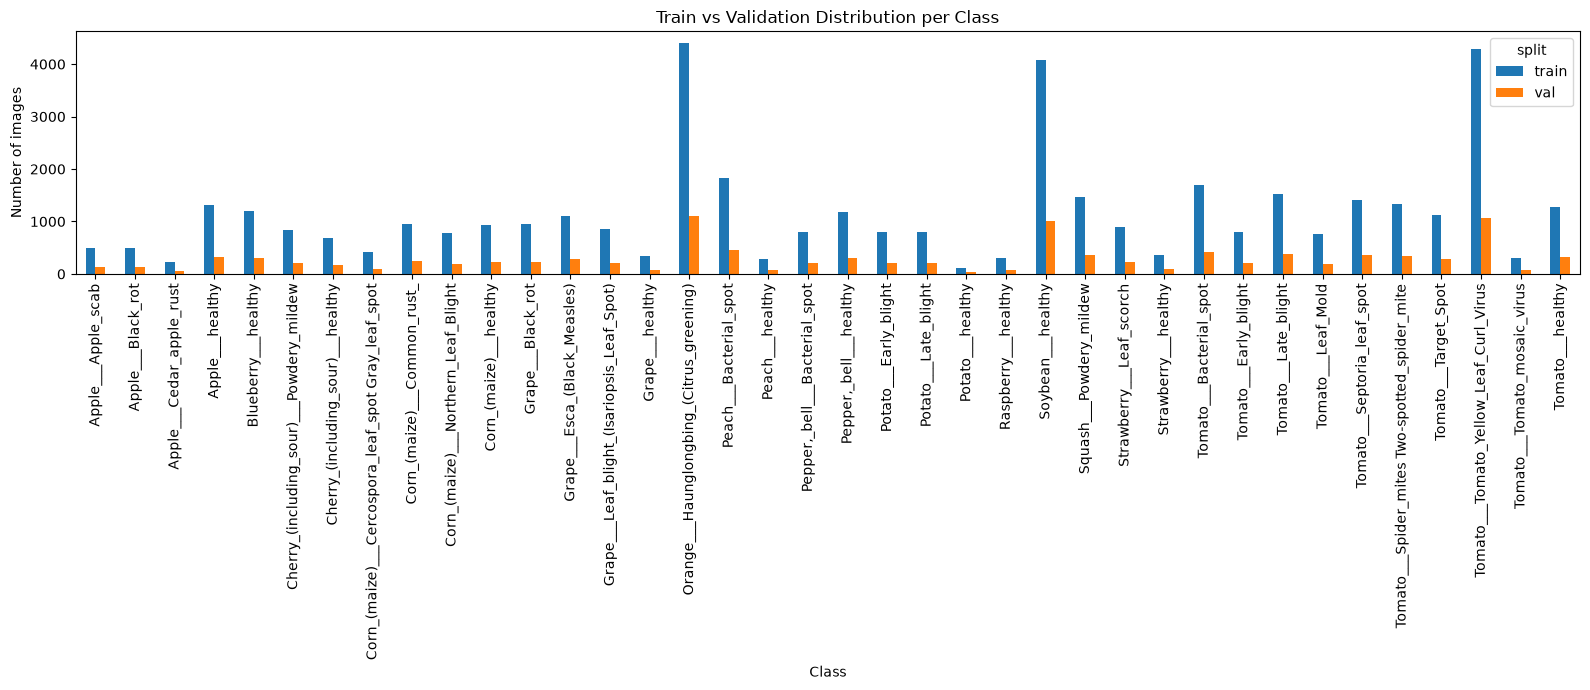

In [68]:
plot_df = (
    df.groupby(
        ["class_name", "split"]
    )
    .size()
    .unstack(fill_value=0)
)

plot_df.plot(
    kind="bar",
    figsize=(16, 7)
)

plt.xlabel("Class")
plt.ylabel("Number of images")
plt.title("Train vs Validation Distribution per Class")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

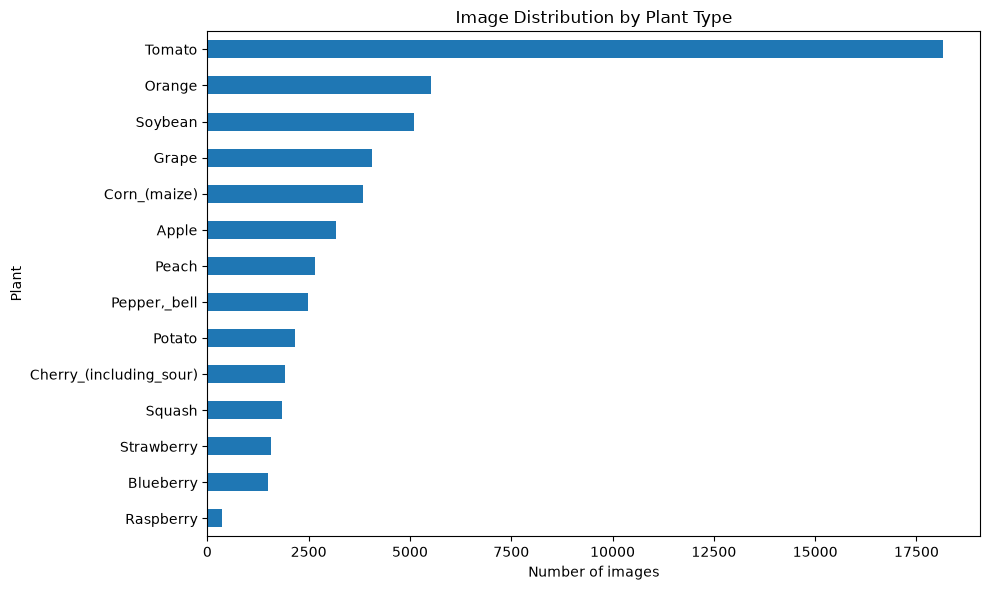

In [69]:
plant_counts = (
    df["plant"]
    .value_counts()
    .sort_values()
)

plt.figure(figsize=(10, 6))

plant_counts.plot(
    kind="barh"
)

plt.xlabel("Number of images")
plt.ylabel("Plant")
plt.title("Image Distribution by Plant Type")

plt.tight_layout()
plt.show()

# Kết luận
- Class nhiều nhất là Orange___Haunglongbing_(Citrus_greening)
- Class nhỏ nhất là Potato___healthy
- Tỉ lệ chênh lệch là 36.23 
- TỈ lệ validation của cả dataset khá đều nhau ở mức 0.2

# V. Hiển thị ảnh mẫu

In [70]:
# Tạo dataframe train

train_df = df[df["split"] == "train"].copy()

In [71]:
# Hiển thị ảnh

def show_samples(df, class_name, n=5):

    samples = df[
        df["class_name"] == class_name
    ].sample(
        n=min(
            n,
            len(df[df["class_name"] == class_name])
        ),
        random_state=42
    )

    plt.figure(figsize=(15, 3))

    for i, (_, row) in enumerate(samples.iterrows()):

        img_path = DATA_DIR / row["relative_path"]

        img = Image.open(img_path)

        plt.subplot(1, len(samples), i + 1)
        plt.imshow(img)
        plt.axis("off")

    plt.suptitle(class_name)
    plt.tight_layout()
    plt.show()

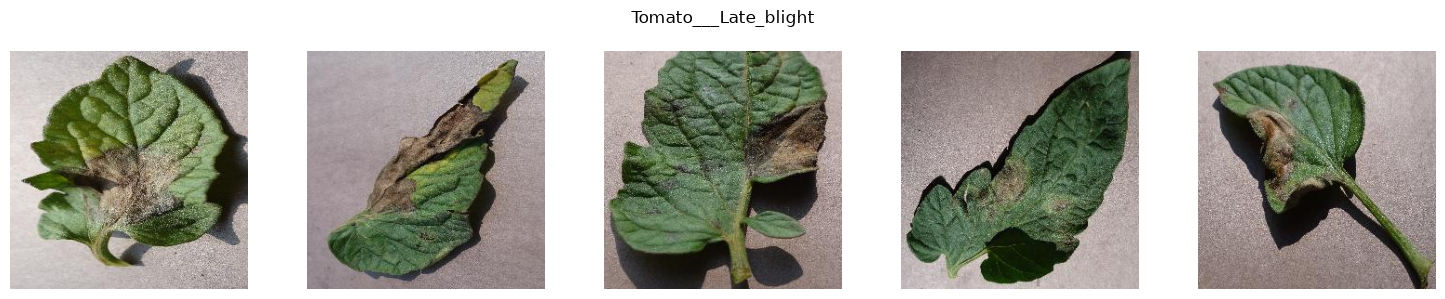

In [72]:
# Ví dụ

show_samples(
    train_df,
    "Tomato___Late_blight",
    n=5
)

In [73]:
# Không nhớ tên class

print(
    df["class_name"]
    .sort_values()
    .unique()
)

<StringArray>
[                                'Apple___Apple_scab',
                                  'Apple___Black_rot',
                           'Apple___Cedar_apple_rust',
                                    'Apple___healthy',
                                'Blueberry___healthy',
           'Cherry_(including_sour)___Powdery_mildew',
                  'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
                        'Corn_(maize)___Common_rust_',
                'Corn_(maize)___Northern_Leaf_Blight',
                             'Corn_(maize)___healthy',
                                  'Grape___Black_rot',
                       'Grape___Esca_(Black_Measles)',
         'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
                                    'Grape___healthy',
           'Orange___Haunglongbing_(Citrus_greening)',
                             'Peach___Bacterial_spot',
                                    'Peach___health

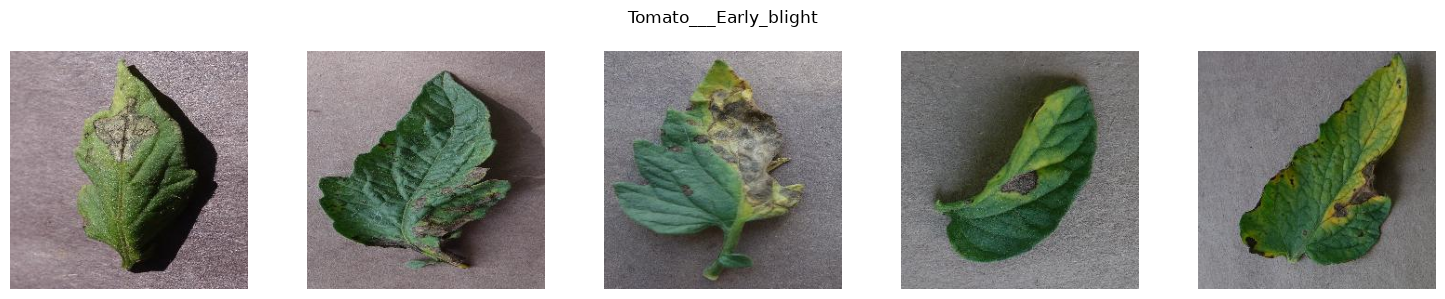

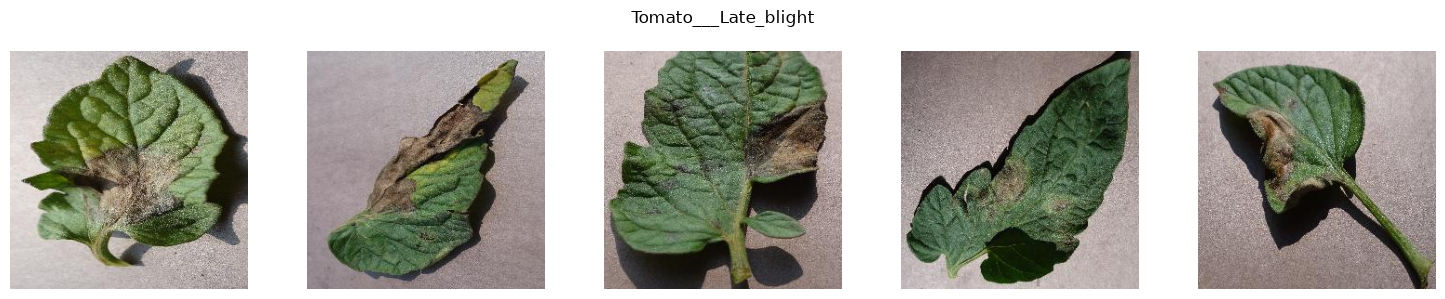

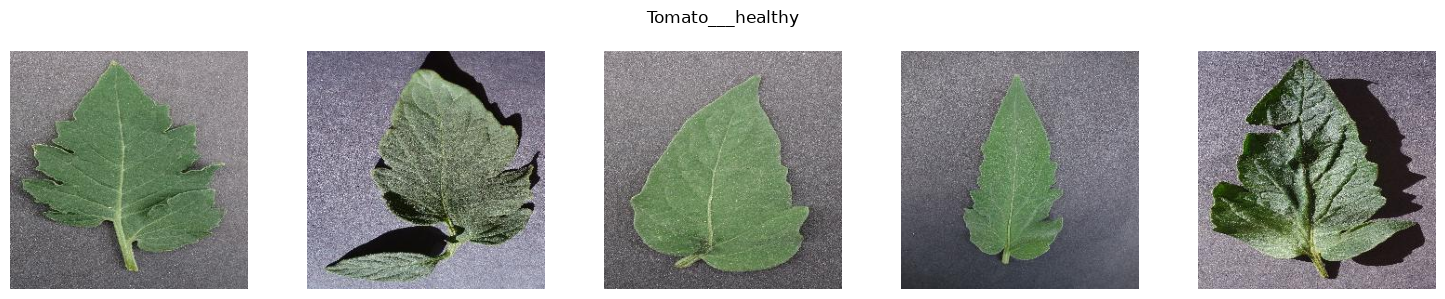

In [74]:
# Xem nhiều class liên tiếp

classes_to_show = [
    "Tomato___Early_blight",
    "Tomato___Late_blight",
    "Tomato___healthy"
]

for cls in classes_to_show:
    show_samples(
        train_df,
        cls,
        n=5
    )

# VI. Kiểm tra kích thước ảnh và kênh màu

In [75]:
from concurrent.futures import ThreadPoolExecutor

def read_image_info(relative_path):
    try:
        with Image.open(DATA_DIR / relative_path) as img:
            return img.width, img.height, img.mode
    except Exception:
        return None, None, None

with ThreadPoolExecutor(max_workers=16) as pool:
    image_info = list(pool.map(read_image_info, df["relative_path"]))

df[["width", "height", "mode"]] = pd.DataFrame(image_info, index=df.index)
df[["relative_path", "width", "height", "mode"]].head()

,relative_path,width,height,mode
0,train\Apple___Apple_scab\01a66316-0e98-4d3b-a5...,256,256,RGB
1,train\Apple___Apple_scab\01f3deaa-6143-4b6c-9c...,256,256,RGB
2,train\Apple___Apple_scab\0208f4eb-45a4-4399-90...,256,256,RGB
3,train\Apple___Apple_scab\023123cb-7b69-4c9f-a5...,256,256,RGB
4,train\Apple___Apple_scab\0261a6e4-21f8-481a-88...,256,256,RGB


In [76]:
# Thống kê kích thước 

df[
    ["width", "height"]
].describe()



,width,height
count,54305.0,54305.0
mean,256.0,256.0
std,0.0,0.0
min,256.0,256.0
25%,256.0,256.0
50%,256.0,256.0
75%,256.0,256.0
max,256.0,256.0


In [77]:
# Bao nhiêu loại

size_counts = (
    df.groupby(["width", "height"])
    .size()
    .sort_values(ascending=False)
)

print(size_counts.to_string())

width  height
256    256       54305


In [78]:
# Kiểm tra mode màu
print(
    df["mode"]
    .value_counts(dropna=False)
    .to_string()
)

mode
RGB     54304
RGBA        1


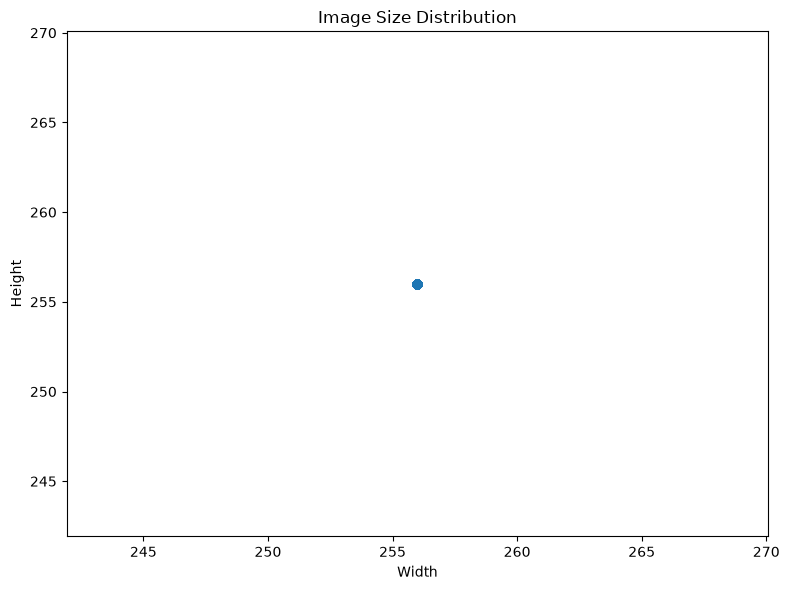

In [79]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df["width"],
    df["height"],
    alpha=0.3
)

plt.xlabel("Width")
plt.ylabel("Height")
plt.title("Image Size Distribution")

plt.tight_layout()
plt.show()

# Tổng kết:
- Gần như toàn bộ dataset các ảnh đều có cùng kích thước và mode màu

# VII. Kiểm tra chất lượng ảnh

# 1. Ảnh không đọc được


In [80]:
def verify_image(relative_path):
    try:
        with Image.open(DATA_DIR / relative_path) as img:
            img.verify()
    except Exception as e:
        return {"relative_path": relative_path, "error": str(e)}
    return None

with ThreadPoolExecutor(max_workers=16) as pool:
    broken_files = [result for result in pool.map(verify_image, df["relative_path"]) if result is not None]

broken_df = pd.DataFrame(broken_files, columns=["relative_path", "error"])
print("Broken images:", len(broken_df))
broken_df

Broken images: 0


""


# 2. Tìm ảnh trùng hoàn toàn

In [81]:


def get_sha256(path):

    h = hashlib.sha256()

    with open(path, "rb") as f:
        for chunk in iter(
            lambda: f.read(8192),
            b""
        ):
            h.update(chunk)

    return h.hexdigest()

In [82]:
with ThreadPoolExecutor(max_workers=16) as pool:
    df["sha256"] = list(pool.map(get_sha256, (DATA_DIR / path for path in df["relative_path"])))

In [83]:
duplicate_df = df[
    df.duplicated(
        subset="sha256",
        keep=False
    )
].sort_values("sha256")

print("Duplicate image rows:", len(duplicate_df))

duplicate_df[
    ["relative_path", "split", "class_name", "sha256"]
]

Duplicate image rows: 42


,relative_path,split,class_name,sha256
51383,val\Tomato___healthy\488feb1c-4b9f-44e7-8aa6-4...,val,Tomato___healthy,12852b3616bcf0ba39b03b5677e74f50f5f6abf4d38957...
32256,train\Tomato___healthy\a5de43e7-fc2f-4a14-a8e6...,train,Tomato___healthy,12852b3616bcf0ba39b03b5677e74f50f5f6abf4d38957...
44074,val\Apple___healthy\fdbfa6f7-f887-442d-8df1-1f...,val,Apple___healthy,262198126fd6d982126b69261723e13abb36b383138797...
2478,train\Apple___healthy\f2cda910-55c7-46d7-b1a2-...,train,Apple___healthy,262198126fd6d982126b69261723e13abb36b383138797...
31687,train\Tomato___healthy\34c81c57-e1fa-49dd-a49d...,train,Tomato___healthy,2a05a74db3a270ac0ec77c00ebe89a332eed5898194351...
51307,val\Tomato___healthy\068e324c-faf6-40d6-8f83-5...,val,Tomato___healthy,2a05a74db3a270ac0ec77c00ebe89a332eed5898194351...
34075,train\Tomato___Late_blight\e5d707cd-077c-43af-...,train,Tomato___Late_blight,2aeb7479e975df37dfb54aa7b403f57f2ad90b018c3780...
33262,train\Tomato___Late_blight\5f21282c-e2ef-4c4a-...,train,Tomato___Late_blight,2aeb7479e975df37dfb54aa7b403f57f2ad90b018c3780...
32478,train\Tomato___healthy\d2ce7896-6fa4-45e6-96c5...,train,Tomato___healthy,32e9ffabaa054c19ae8df95e94fbd7a25105defdea1214...
32191,train\Tomato___healthy\9662364c-aaba-45e3-b907...,train,Tomato___healthy,32e9ffabaa054c19ae8df95e94fbd7a25105defdea1214...


In [84]:
duplicate_df.to_csv(
    "../data/metadata/duplicate_images.csv",
    index=False
)

# 3. Kiểm tra duplicate giữa train và val

In [85]:
duplicate_cross_split = (
    duplicate_df
    .groupby("sha256")["split"]
    .nunique()
)

cross_split_hashes = duplicate_cross_split[
    duplicate_cross_split > 1
].index

In [86]:
cross_split_duplicates = duplicate_df[
    duplicate_df["sha256"].isin(
        cross_split_hashes
    )
]

cross_split_duplicates[
    ["relative_path", "split", "class_name", "sha256"]
]

,relative_path,split,class_name,sha256
51383,val\Tomato___healthy\488feb1c-4b9f-44e7-8aa6-4...,val,Tomato___healthy,12852b3616bcf0ba39b03b5677e74f50f5f6abf4d38957...
32256,train\Tomato___healthy\a5de43e7-fc2f-4a14-a8e6...,train,Tomato___healthy,12852b3616bcf0ba39b03b5677e74f50f5f6abf4d38957...
44074,val\Apple___healthy\fdbfa6f7-f887-442d-8df1-1f...,val,Apple___healthy,262198126fd6d982126b69261723e13abb36b383138797...
2478,train\Apple___healthy\f2cda910-55c7-46d7-b1a2-...,train,Apple___healthy,262198126fd6d982126b69261723e13abb36b383138797...
31687,train\Tomato___healthy\34c81c57-e1fa-49dd-a49d...,train,Tomato___healthy,2a05a74db3a270ac0ec77c00ebe89a332eed5898194351...
51307,val\Tomato___healthy\068e324c-faf6-40d6-8f83-5...,val,Tomato___healthy,2a05a74db3a270ac0ec77c00ebe89a332eed5898194351...
43841,val\Apple___healthy\3d075f90-7002-4c45-abc0-4f...,val,Apple___healthy,6b242d89b134aa87000f8397d0e85f8448e3b3d607d3b7...
2126,train\Apple___healthy\acb21cc2-8d65-4880-a7bb-...,train,Apple___healthy,6b242d89b134aa87000f8397d0e85f8448e3b3d607d3b7...
51747,val\Tomato___Late_blight\5688ea99-c949-41d0-bb...,val,Tomato___Late_blight,6e1610d4e0f6f84108af112322d11779254b2b2d419584...
34045,train\Tomato___Late_blight\e20107e7-137f-400e-...,train,Tomato___Late_blight,6e1610d4e0f6f84108af112322d11779254b2b2d419584...


In [87]:
print(
    "Duplicate groups across train/val:",
    len(cross_split_hashes)
)

Duplicate groups across train/val: 10


# 4. Kiểm tra cùng ảnh nhưng khác label

In [88]:
label_counts_per_hash = (
    duplicate_df
    .groupby("sha256")["class_name"]
    .nunique()
)

suspicious_hashes = label_counts_per_hash[
    label_counts_per_hash > 1
].index

In [89]:
label_conflict_df = duplicate_df[
    duplicate_df["sha256"].isin(
        suspicious_hashes
    )
]

label_conflict_df[
    ["relative_path", "class_name", "sha256"]
]

,relative_path,class_name,sha256


# 5. Tìm ảnh gần trùng

In [90]:
def get_phash(path):

    try:
        with Image.open(path) as img:
            return imagehash.phash(
                img.convert("RGB")
            )

    except Exception:
        return None

In [91]:
with ThreadPoolExecutor(max_workers=16) as pool:
    df["phash"] = [str(value) if value is not None else None for value in pool.map(
        get_phash, (DATA_DIR / path for path in df["relative_path"])
    )]

In [92]:
near_duplicates = []

for class_name, group in df.groupby("class_name"):
    valid_rows = group[group["phash"].notna() & group["phash"].ne("None")]
    # XOR bit count is the Hamming distance used by ImageHash.
    hashes = [int(value, 16) for value in valid_rows["phash"]]
    paths = valid_rows["relative_path"].tolist()

    for i in range(len(hashes)):
        for j in range(i + 1, len(hashes)):
            distance = (hashes[i] ^ hashes[j]).bit_count()
            if distance <= 5:
                near_duplicates.append({
                    "class_name": class_name,
                    "image_1": paths[i],
                    "image_2": paths[j],
                    "phash_distance": distance
                })

In [93]:
near_duplicate_df = pd.DataFrame(
    near_duplicates
)

print(
    "Near duplicate pairs:",
    len(near_duplicate_df)
)

near_duplicate_df.head()

Near duplicate pairs: 1165


,class_name,image_1,image_2,phash_distance
0,Apple___Black_rot,train\Apple___Black_rot\30aebb07-bde6-44c8-bee...,train\Apple___Black_rot\fb8255a6-e05d-44d3-a11...,4
1,Apple___Black_rot,train\Apple___Black_rot\4eeaca51-3ca2-4afe-884...,train\Apple___Black_rot\fc5f6bd3-bd4e-4a8c-94d...,4
2,Apple___Black_rot,train\Apple___Black_rot\6af96fb3-002f-48b3-a2e...,train\Apple___Black_rot\f83c1286-8bdb-48e6-ac8...,4
3,Apple___healthy,train\Apple___healthy\11beda66-01e9-4bfd-be37-...,val\Apple___healthy\13298d36-4425-437d-ae8e-c7...,0
4,Apple___healthy,train\Apple___healthy\14896dc0-688d-456f-b5ec-...,train\Apple___healthy\c21cf428-bfc3-4710-b5d2-...,0


In [94]:
near_duplicate_df.to_csv(
    "../data/metadata/near_duplicates.csv",
    index=False
)

# Kết luận
- Không có ảnh nào không đọc được 
- 42 ảnh bị trùng hoàn toàn
- 10 cặp trùng giữa train và val có thể gây data leakage
- Không có ảnh nào bị trùng nhưng khác label
- Có 1165 ảnh gần giống nhau